# **使用LeNet算法实现手写数字识别**

## 注意事项

1、本案例使用AI框架：**MindSpore1.1.1**。

2、本案例最低硬件规格要求：**8vCPU + 32GiB**。

3、切换硬件规格的方法：如需切换硬件规格，您可以在本页面右边的工作区进行切换。

4、运行代码方法：点击本页面顶部菜单栏的三角形运行按钮或按Ctrl + Enter键运行每个方块中的代码。

5、JupyterLab的详细用法：[请参考《ModelAtrs JupyterLab使用指导》](https://bbs.huaweicloud.com/forum/thread-97603-1-1.html)

6、Kernel Restarting、Kernel died及其他常见问题的解决办法： [请参考《ModelAtrs JupyterLab常见问题解决办法》](https://bbs.huaweicloud.com/forum/thread-98681-1-1.html)

## MindSpore介绍

MindSpore是一个全场景深度学习框架，旨在实现易开发、高效执行、全场景覆盖三大目标

- 易开发表现为API友好、调试难度低，

- 高效执行包括计算效率、数据预处理效率和分布式训练效率，

- 全场景则指框架同时支持云、边缘以及端侧场景。

MindSpore提供了Python编程范式，用户使用Python原生控制逻辑即可构建复杂的神经网络模型，AI编程变得简单。

### 特点

目前主流的深度学习框架的执行模式有两种，分别为静态图模式和动态图模式。静态图模式拥有较高的训练性能，但难以调试。动态图模式相较于静态图模式虽然易于调试，但难以高效执行。

MindSpore提供了动态图和静态图统一的编码方式，大大增加了静态图和动态图的可兼容性，用户无需开发多套代码，仅变更一行代码便可切换动态图/静态图模式

## 实验目标

本Notebook将展示如何使用MindSpore在MNIST数据集上开发和训练一个LeNet模型，并将LeNet模型用于手写数字识别。

通过本实验你可以了解到如何使用MindSpore进行简单CNN网络的开发、简单图片分类任务的训和验证。

## 实验步骤

In [1]:
# 确认当前环境的版本为 mindspore1.1.1
import mindspore
print(mindspore.__version__)

[WARNING] ME(335:140178881218368,MainProcess):2021-03-25-18:57:44.695.9 [mindspore/ops/operations/array_ops.py:2302] WARN_DEPRECATED: The usage of Pack is deprecated. Please use Stack.


1.1.1


### 1、数据集下载
MNIST是一个手写数字数据集，训练集包含60000张手写数字，测试集包含10000张手写数字，共10类。

从华为云OBS公共桶中下载

In [2]:
!wget -N https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com/course/hwc_edu/python_module_framework/datasets/mindspore_data/MNIST_Data.zip
!unzip -o MNIST_Data.zip -d ./
!tree ./MNIST_Data/

--2021-03-25 18:57:45--  https://modelarts-labs-bj4.obs.cn-north-4.myhuaweicloud.com/course/hwc_edu/python_module_framework/datasets/mindspore_data/MNIST_Data.zip
Resolving proxy-notebook.modelarts-dev-proxy.com (proxy-notebook.modelarts-dev-proxy.com)... 192.168.0.172
Connecting to proxy-notebook.modelarts-dev-proxy.com (proxy-notebook.modelarts-dev-proxy.com)|192.168.0.172|:8083... connected.
Proxy request sent, awaiting response... 200 OK
Length: 10754903 (10M) [application/zip]
Saving to: ‘MNIST_Data.zip’

MNIST_Data.zip      100%[===================>]  10.26M  40.5MB/s    in 0.3s    

2021-03-25 18:57:46 (40.5 MB/s) - ‘MNIST_Data.zip’ saved [10754903/10754903]

Archive:  MNIST_Data.zip
   creating: ./MNIST_Data/test/
  inflating: ./MNIST_Data/test/t10k-images-idx3-ubyte  
  inflating: ./MNIST_Data/test/t10k-labels-idx1-ubyte  
   creating: ./MNIST_Data/train/
  inflating: ./MNIST_Data/train/train-images-idx3-ubyte  
  inflating: ./MNIST_Data/train/train-labels-idx1-ubyte  
./MNIST

### 2、处理MNIST数据集

由于我们后面会采用LeNet这样的卷积神经网络对数据集进行训练，而采用LeNet在训练数据时，对数据格式是有所要求的，所以接下来的工作需要我们先查看数据集内的数据是什么样的，这样才能构造一个针对性的数据转换函数，将数据集数据转换成符合训练要求的数据形式。

#### 步骤1 查看原始数据集数据

The type of mnist_ds: <class 'mindspore.dataset.engine.datasets.MnistDataset'>
Number of pictures contained in the mnist_ds： 60000
The item of mnist_ds: dict_keys(['image', 'label'])
Tensor of image in item: (28, 28, 1)
The label of item: 1


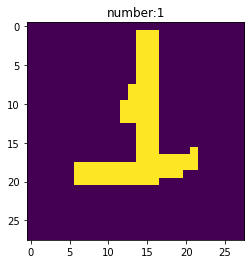

In [3]:
from mindspore import context
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import mindspore.dataset as ds

# device_target 可选 CPU/GPU/Ascend, 当选择GPU时mindspore规格也需要切换到GPU
context.set_context(mode=context.GRAPH_MODE, device_target="CPU") 
# device_id = int(os.getenv("DEVICE_ID"))
# context.set_context(mode=context.GRAPH_MODE, device_target="Ascend", device_id=device_id)
train_data_path = "./MNIST_Data/train"
test_data_path = "./MNIST_Data/test"
mnist_ds = ds.MnistDataset(train_data_path)
print('The type of mnist_ds:', type(mnist_ds))
print("Number of pictures contained in the mnist_ds：", mnist_ds.get_dataset_size())

dic_ds = mnist_ds.create_dict_iterator()
item = next(dic_ds)
img = item["image"].asnumpy()
label = item["label"].asnumpy()

print("The item of mnist_ds:", item.keys())
print("Tensor of image in item:", img.shape) 
print("The label of item:", label)

plt.imshow(np.squeeze(img))
plt.title("number:%s"% item["label"].asnumpy())
plt.show()

#### 步骤2 数据处理

数据集对于训练非常重要，好的数据集可以有效提高训练精度和效率，在加载数据集前，我们通常会对数据集进行一些处理。

**定义数据集及数据操作**

定义完成后，使用`create_datasets`对原始数据进行增强操作，并抽取一个`batch`的数据，查看数据增强后的变化。

In [4]:
import mindspore.dataset.vision.c_transforms as CV
import mindspore.dataset.transforms.c_transforms as C
from mindspore.dataset.vision import Inter
from mindspore import dtype as mstype


def create_dataset(data_path, batch_size=32, repeat_size=1,
                   num_parallel_workers=1):
    """ 
    create dataset for train or test
    
    Args:
        data_path (str): Data path
        batch_size (int): The number of data records in each group
        repeat_size (int): The number of replicated data records
        num_parallel_workers (int): The number of parallel workers
    """
    # define dataset
    mnist_ds = ds.MnistDataset(data_path)

    # define some parameters needed for data enhancement and rough justification
    resize_height, resize_width = 32, 32
    rescale = 1.0 / 255.0
    shift = 0.0
    rescale_nml = 1 / 0.3081
    shift_nml = -1 * 0.1307 / 0.3081

    # according to the parameters, generate the corresponding data enhancement method
    resize_op = CV.Resize((resize_height, resize_width), interpolation=Inter.LINEAR)
    rescale_nml_op = CV.Rescale(rescale_nml, shift_nml)
    rescale_op = CV.Rescale(rescale, shift)
    hwc2chw_op = CV.HWC2CHW()
    type_cast_op = C.TypeCast(mstype.int32)

    # using map to apply operations to a dataset
    mnist_ds = mnist_ds.map(operations=type_cast_op, input_columns="label", num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(operations=resize_op, input_columns="image", num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(operations=rescale_op, input_columns="image", num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(operations=rescale_nml_op, input_columns="image", num_parallel_workers=num_parallel_workers)
    mnist_ds = mnist_ds.map(operations=hwc2chw_op, input_columns="image", num_parallel_workers=num_parallel_workers)
    
    # process the generated dataset
    buffer_size = 10000
    mnist_ds = mnist_ds.shuffle(buffer_size=buffer_size)
    mnist_ds = mnist_ds.batch(batch_size, drop_remainder=True)
    mnist_ds = mnist_ds.repeat(repeat_size)

    return mnist_ds

ms_dataset = create_dataset(train_data_path)
print('Number of groups in the dataset:', ms_dataset.get_dataset_size())

Number of groups in the dataset: 1875


调用数据增强函数后，查看数据集`size`由60000变成了1875，符合我们的数据增强中`mnist_ds.batch`操作的预期（$60000/32=1875$）。

#### 步骤3 进一步查看增强后的数据

从1875组数据中取出一组数据查看其数据张量及`label`。

In [5]:
data = next(ms_dataset.create_dict_iterator(output_numpy=True))
images = data["image"]
labels = data["label"]
print('Tensor of image:', images.shape)
print('labels:', labels)

Tensor of image: (32, 1, 32, 32)
labels: [1 4 4 2 5 5 6 9 4 6 0 6 7 4 2 6 2 9 9 8 9 6 1 3 6 0 4 4 7 2 2 4]


将张量数据和下标对应的值进行可视化。

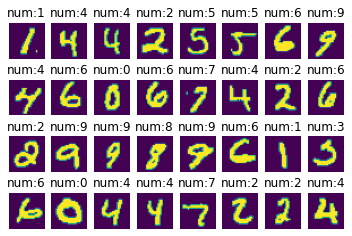

In [6]:
count = 1
for i in images:
    plt.subplot(4, 8, count) 
    plt.imshow(np.squeeze(i))
    plt.title('num:%s'%labels[count-1])
    plt.xticks([])
    count += 1
    plt.axis("off")
plt.show()

### 3、 定义模型

在对手写字体识别上，通常采用卷积神经网络架构（CNN）进行学习预测，最经典的属1998年由Yann LeCun创建的LeNet5架构，<br/>结构示意如下图：

 **LeNet5结构图**

<img src="https://gitee.com/mindspore/docs/raw/master/tutorials/training/source_zh_cn/quick_start/images/LeNet_5.jpg" alt="LeNet5">

更多的LeNet网络的介绍不在此赘述，希望详细了解LeNet网络，可以查询<http://yann.lecun.com/exdb/lenet/>。

In [7]:
import mindspore.nn as nn
from mindspore.common.initializer import Normal

class LeNet5(nn.Cell):
    """Lenet network structure."""
    # define the operator required
    def __init__(self, num_class=10, num_channel=1):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(num_channel, 6, 5, pad_mode='valid')
        self.conv2 = nn.Conv2d(6, 16, 5, pad_mode='valid')
        self.fc1 = nn.Dense(16 * 5 * 5, 120, weight_init=Normal(0.02))
        self.fc2 = nn.Dense(120, 84, weight_init=Normal(0.02))
        self.fc3 = nn.Dense(84, num_class, weight_init=Normal(0.02))
        self.relu = nn.ReLU()
        self.max_pool2d = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

    # use the preceding operators to construct networks
    def construct(self, x):
        x = self.max_pool2d(self.relu(self.conv1(x)))
        x = self.max_pool2d(self.relu(self.conv2(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x) 
        return x
    
network = LeNet5()
print("layer conv1:", network.conv1)
print("*"*40)
print("layer fc1:", network.fc1)

layer conv1: Conv2d<input_channels=1, output_channels=6, kernel_size=(5, 5),stride=(1, 1),  pad_mode=valid, padding=0, dilation=(1, 1), group=1, has_bias=Falseweight_init=normal, bias_init=zeros, format=NCHW>
****************************************
layer fc1: Dense<input_channels=400, output_channels=120, has_bias=True>


### 4、搭建训练网络并进行训练

构建完成神经网络后，就可以着手进行训练网络的构建，模型训练函数为`Model.train`

In [8]:
import os
from mindspore import Tensor, Model
from mindspore import load_checkpoint, load_param_into_net
from mindspore.train.callback import ModelCheckpoint, CheckpointConfig, LossMonitor
from mindspore.nn.metrics import Accuracy
from mindspore.nn.loss import SoftmaxCrossEntropyWithLogits

lr = 0.01
momentum = 0.9 
epoch_size = 1
mnist_path = "./MNIST_Data"
model_path = "./models/ckpt/"

# clean up old run files before in Linux
os.system('rm -f {}*.ckpt {}*.meta {}*.pb'.format(model_path, model_path, model_path))

# create the network
network = LeNet5()

# define the optimizer
net_opt = nn.Momentum(network.trainable_params(), lr, momentum)

# define the loss function
net_loss = SoftmaxCrossEntropyWithLogits(sparse=True, reduction='mean')

# define the model
model = Model(network, net_loss, net_opt, metrics={"Accuracy": Accuracy()} )

# save the network model and parameters for subsequence fine-tuning
config_ck = CheckpointConfig(save_checkpoint_steps=375, keep_checkpoint_max=16)
# group layers into an object with training and evaluation features
ckpoint_cb = ModelCheckpoint(prefix="checkpoint_lenet", directory=model_path, config=config_ck)


eval_dataset = create_dataset("./MNIST_Data/test")

step_loss = {"step": [], "loss_value": []}
steps_eval = {"step": [], "acc": []}

repeat_size = 1
ds_train = create_dataset(os.path.join(mnist_path, "train"), 32, repeat_size)

model.train(epoch_size, ds_train, callbacks=[ckpoint_cb, LossMonitor(125)], dataset_sink_mode=False)

epoch: 1 step: 125, loss is 2.3139029
epoch: 1 step: 250, loss is 2.3007612
epoch: 1 step: 375, loss is 2.3227825
epoch: 1 step: 500, loss is 2.2920208
epoch: 1 step: 625, loss is 0.39024204
epoch: 1 step: 750, loss is 0.6207354
epoch: 1 step: 875, loss is 0.42038798
epoch: 1 step: 1000, loss is 0.19011219
epoch: 1 step: 1125, loss is 0.23346587
epoch: 1 step: 1250, loss is 0.08591945
epoch: 1 step: 1375, loss is 0.16881402
epoch: 1 step: 1500, loss is 0.05662374
epoch: 1 step: 1625, loss is 0.26829973
epoch: 1 step: 1750, loss is 0.2920754
epoch: 1 step: 1875, loss is 0.056083374


###  5、测试数据验证模型精度

In [9]:
# testing relate modules 
def test_net(network, model, mnist_path):
    """Define the evaluation method."""
    print("============== Starting Testing ==============")
    # load the saved model for evaluation
    param_dict = load_checkpoint("./models/ckpt/checkpoint_lenet-1_1875.ckpt")
    # load parameter to the network
    load_param_into_net(network, param_dict)
    # load testing dataset
    ds_eval = create_dataset(os.path.join(mnist_path, "test"))
    acc = model.eval(ds_eval, dataset_sink_mode=False)
    print("============== Accuracy:{} ==============".format(acc))

test_net(network, model, mnist_path)

============== Starting Testing ==============
============== Accuracy:{'Accuracy': 0.9673477564102564} ==============


### 6、推理（训练后）

我们尝试使用生成的模型应用到分类预测单个或者单组图片数据上，可以看到识别结果基本上是正确的。

All the figures in this group are predicted correctly!
[3 2 5 0 2 2 7 8 4 5 4 5 9 2 8 7 6 1 1 4 3 4 6 7 7 7 3 8 1 3 9 7] <--Predicted figures
[3 2 5 0 2 2 7 8 4 5 4 5 9 2 8 7 6 1 1 4 3 4 6 7 7 7 3 8 1 3 9 7] <--The right number


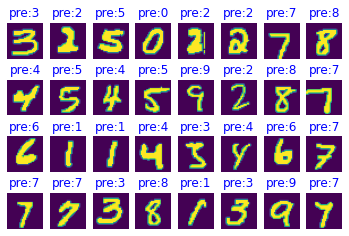

In [10]:
ds_test = create_dataset(test_data_path).create_dict_iterator()
data = next(ds_test)
images = data["image"].asnumpy()
labels = data["label"].asnumpy()

output = model.predict(Tensor(data['image']))
pred = np.argmax(output.asnumpy(), axis=1)
err_num = []
index = 1
for i in range(len(labels)):
    plt.subplot(4, 8, i+1)
    color = 'blue' if pred[i] == labels[i] else 'red'
    plt.title("pre:{}".format(pred[i]), color=color)
    plt.imshow(np.squeeze(images[i]))
    plt.axis("off")
    if color == 'red':
        index = 0
        print("Row {}, column {} is incorrectly identified as {}, the correct value should be {}".format(int(i/8)+1, i%8+1, pred[i], labels[i]), '\n')
if index:
    print("All the figures in this group are predicted correctly!")
print(pred, "<--Predicted figures") 
print(labels, "<--The right number")
plt.show()

## 小结

本实验展示了如何使用MindSpore进行手写数字识别，以及开发和训练LeNet5模型。通过对LeNet5模型做几代的训练，然后使用训练后的LeNet5模型对手写数字进行识别，识别准确率大于95%。即LeNet5学习到了如何进行手写数字识别。

至此，本案例完成。